# HDX Metadata API Endpoints: Jupyter Notebook

This notebook demonstrates how to use HDX's metadata API endpoints with Python to discover, analyze, and automate access to humanitarian data on HDX. It also includes visualizations for the type of data on HDX and an advanced section on how to use the Tabular Data Endpoints for full analysis.

**Please note:**
- These are public endpoints. However, there is stricter rate limiting on API calls without an API token. If you are pulling many requests it is recommended to use an API token. Do not commit or share it. Treat it like a password!
- This notebook is designed for specific datasets. If you would like to adjust to other datasets, you must change the dataset ID or name.
- Use the [HDX Metadata API documentation](https://docs.humdata.org/build/hdx-apis/metadata-endpoints) to answer any other questions!

## Setup & configuration

First, let's install required packages, import libraries, and define shared helper functions which are used throughout the notebook.

In [1]:
# Install required packages (uncomment if needed)
#!pip install requests pandas matplotlib geopandas contextily

In [2]:
import time
import json
import os
import urllib.parse
import requests
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import io, zipfile, tempfile
from pathlib import Path

In [3]:
# Base API URL for all HDX endpoints
BASE_URL = "https://data.humdata.org/api/action"

# Make a GET request to an HDX metadata endpoint and return the JSON response
def call_hdx_api(endpoint, params=None):
    url = f"{BASE_URL}/{endpoint}"
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

# Plot a horizontal bar chart of the top-n facet results (e.g. countries or organisations).
def plot_top_facets(df, label_col, count_col, title, color="steelblue", n=20):
    top = df.head(n)
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(top)), top[count_col], color=color)
    plt.yticks(range(len(top)), top[label_col])
    plt.xlabel("Number of Datasets")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print("✓ Setup complete!")

✓ Setup complete!


### Tabular Data Endpoint Helpers (Only used in the Advanced section)

The functions below are used in the **Advanced** section to query data content directly via the [Tabular Data Endpoints](https://github.com/OCHA-DAP/hdx-tabular-data-endpoints-notebook). They are defined here so they are available for the whole notebook. See more documentation [here](https://docs.humdata.org/build/hdx-apis/tabular-data-endpoints).

They require an `HDX_API_TOKEN` environment variable. Set this before running the Advanced section.

In [4]:
# Load HDX API token from environment (required for Tabular Data Endpoints)
# Skip this cell if you only intend to run Use Cases 1–4
API_TOKEN = os.getenv("HDX_API_TOKEN")
HEADERS = {"Authorization": API_TOKEN} if API_TOKEN else {}

if API_TOKEN:
    print("✓ HDX_API_TOKEN loaded successfully.")
else:
    print("ℹ HDX_API_TOKEN not set — Tabular Data Endpoint calls will be unauthenticated.")

# Print the field schema for a TDE resource
def show_schema(resource_id, label):
    url = f"{BASE_URL}/datastore_info?{urllib.parse.urlencode({'id': resource_id})}"
    data = requests.get(url, headers=HEADERS).json()
    if not data.get("success"):
        raise RuntimeError(f"Schema request failed: {data}")
    result = data["result"]
    fields = result.get("fields", [])
    primary_key = set(result.get("primary_key", []))
    indexed_cols = {
        i for idx in result.get("indexes", [])
        for i in ([idx] if isinstance(idx, str) else idx)
    }
    print(f"{label} schema ({len(fields)} fields):")
    for f in fields:
        is_index = f["id"] in primary_key or f["id"] in indexed_cols
        print(f"  {f['id']}: {f['type']} | is_index={is_index}")

# GET request with exponential back-off for rate-limit / server errors
def _get_with_backoff(url, tries=5, timeout=60):
    for i in range(tries):
        r = requests.get(url, headers=HEADERS, timeout=timeout)
        if r.status_code in (429, 500, 502, 503, 504):
            time.sleep(2 ** i)
            continue
        r.raise_for_status()
        return r.json()
    raise RuntimeError(f"Request failed after {tries} tries: {url}")

# Query a single page of records from an HDX TDE resource
def datastore_search(resource_id, limit=32000, offset=0, filters=None, fields=None):
    params = {"resource_id": resource_id, "limit": limit, "offset": offset}
    if filters:
        params["filters"] = json.dumps(filters)
    if fields:
        params["fields"] = ",".join(fields)
    url = f"{BASE_URL}/datastore_search?{urllib.parse.urlencode(params)}"
    return _get_with_backoff(url)

# Fetch all records from a TDE resource, paginating automatically
def fetch_all_records(resource_id, page_size=32000, filters=None, fields=None):
    out, offset = [], 0
    while True:
        resp = datastore_search(resource_id, limit=page_size, offset=offset,
                                filters=filters, fields=fields)
        if not resp.get("success"):
            raise RuntimeError(f"API failure: {resp}")
        result = resp["result"]
        rows = result.get("records", [])
        if not rows:
            break
        out.extend(rows)
        offset += len(rows)
        if offset >= result.get("total", 0):
            break
    return pd.DataFrame(out)

✓ HDX_API_TOKEN loaded successfully.


## Use Case 1: Discover Datasets by Topic/Country

The metadata endpoints are ideal for searching the HDX catalogue. In this example we want to find all datasets related to **"displacement"** in **Somalia**, sorted by most recently updated. This could be used to identify which organisations publish displacement data when scoping a new project. First, let's walk through `fq`.

### Understanding `fq` (filter query)

Alongside the full-text `q` parameter, HDX Metadata Endpoints support an `fq` (filter query) parameter for structured field-level filtering. Common fields include:

| Filter | Example | Definition |
|:---|:---|:---|
| `groups` | `groups:som` | Country (ISO 3-letter code) |
| `organization` | `organization:unhcr` | Publisher organisation |
| `res_format` | `res_format:CSV` | Resource file format |
| `+` prefix | `+groups:afg` | AND-combine multiple filters |

See the [HDX group list](https://data.humdata.org/group) for all country codes.

In [5]:
# Search for displacement datasets in Somalia, sorted by most recently updated
params = {
    'q': 'displacement',             # Full-text search term
    'fq': 'groups:som',              # Filter to Somalia (ISO code: som)
    'rows': 10,                      # Return top 10 results
    'sort': 'metadata_modified desc' # Most recently updated first
}

response = call_hdx_api('package_search', params)
print(f"Found {response['result']['count']} datasets matching 'displacement' in Somalia")

Found 70 datasets matching 'displacement' in Somalia


In [6]:
# Extract key fields into a DataFrame for easy inspection
datasets = [
    {
        'Title': d['title'],
        'Organization': d['organization']['title'],
        'Last Updated': d['metadata_modified'][:10],
        'Resources': len(d['resources']),
        'URL': f"https://data.humdata.org/dataset/{d['name']}"
    }
    for d in response['result']['results']
]

df_datasets = pd.DataFrame(datasets)
df_datasets

,Title,Organization,Last Updated,Resources,URL
0,Somalia - Internal Displacements Updates (IDU)...,Internal Displacement Monitoring Centre (IDMC),2026-02-18,1,https://data.humdata.org/dataset/idmc-event-da...
1,UNHCR Situations: Monthly Refugees and Asylum ...,UNHCR - The UN Refugee Agency,2026-02-18,1,https://data.humdata.org/dataset/unhcr-situations
2,HDX HAPI Data for Somalia,HDX Humanitarian API Data,2026-02-18,13,https://data.humdata.org/dataset/hdx-hapi-som
3,Somalia Displacement - [IDPs] - Emergency Tre...,International Organization for Migration (IOM),2026-02-17,3,https://data.humdata.org/dataset/somalia-displ...
4,Somalia District hit by 2019 Tropical Cyclone ...,IGAD Climate Prediction and Applications Cente...,2026-02-17,4,https://data.humdata.org/dataset/icpac-geonode...
5,Somalia Districts hit by 2018 Tropical Cyclone...,IGAD Climate Prediction and Applications Cente...,2026-02-17,4,https://data.humdata.org/dataset/icpac-geonode...
6,Somalia Districts hit by 2010 Tropical Cyclone...,IGAD Climate Prediction and Applications Cente...,2026-02-17,4,https://data.humdata.org/dataset/icpac-geonode...
7,Somalia Regions hit by 2010 Tropical Cyclone B...,IGAD Climate Prediction and Applications Cente...,2026-02-17,4,https://data.humdata.org/dataset/icpac-geonode...
8,2020 Tropical Cyclone Gati Path,IGAD Climate Prediction and Applications Cente...,2026-02-17,4,https://data.humdata.org/dataset/icpac-geonode...
9,Somalia Districts hit by 2013 Tropical Cyclone 3A,IGAD Climate Prediction and Applications Cente...,2026-02-17,4,https://data.humdata.org/dataset/icpac-geonode...


## Use Case 2: Platform Analytics Using Facets

HDX's facet queries let you aggregate counts across the entire catalogue without returning individual dataset records by setting `rows=0` and specifying a `facet.field`. You can aggregate data for specific parameters within an API response directly rather than having to perform analytics on the data. This is useful for:

- Understanding data availability by country
- Identifying key data contributors
- Platform reporting and analytics

In [7]:
# Get dataset counts by country using facets
params = {
    'q': '*:*',           # Match all datasets
    'rows': 0,            # Setting rows=0 returns only aggregate counts, not individual datasets which much faster!
    'facet.field': '["groups"]', # Groups is HDX countries
    'facet.limit': 250    # Up to 250 countries
}

response = call_hdx_api('package_search', params)
print(f"Total datasets on HDX: {response['result']['count']}")

country_facets = response['result']['search_facets']['groups']['items']
country_df = pd.DataFrame([
    {'Country': item['display_name'], 'Dataset Count': item['count']}
    for item in country_facets
]).sort_values('Dataset Count', ascending=False)

print(f"\nDatasets available for {len(country_df)} countries/regions")
country_df.head(20)

Total datasets on HDX: 26456

Datasets available for 250 countries/regions


,Country,Dataset Count
4,World,803
44,Somalia,559
132,Kenya,538
175,Ethiopia,525
199,Colombia,523
41,South Sudan,478
249,Afghanistan,453
37,Sudan,434
187,Democratic Republic of the Congo,430
89,Nigeria,426


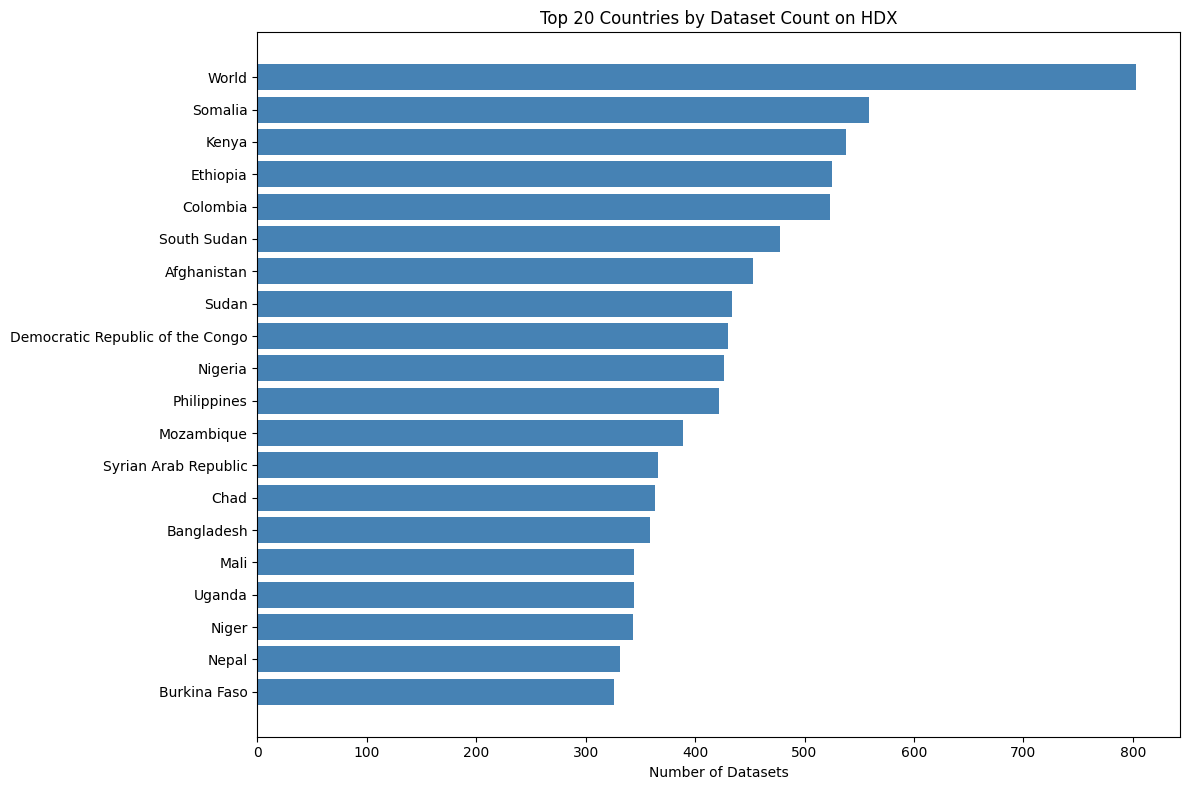

In [8]:
# Visualization of top 20 countries
plot_top_facets(country_df, 'Country', 'Dataset Count',
               title='Top 20 Countries by Dataset Count on HDX')

In [9]:
# Now break down by publishing HDX organisation
params = {
    'q': '*:*',
    'rows': 0,
    'facet.field': '["organization"]',
    'facet.limit': 50
}

response = call_hdx_api('package_search', params)
org_facets = response['result']['search_facets']['organization']['items']

org_df = pd.DataFrame([
    {'Organization': item['display_name'], 'Dataset Count': item['count']}
    for item in org_facets
]).sort_values('Dataset Count', ascending=False)

org_df.head(20)

,Organization,Dataset Count
4,World Bank Group,4792
36,Humanitarian OpenStreetMap Team (HOT),2611
2,WorldPop,1569
8,United Nations Satellite Centre (UNOSAT),1454
12,UNHCR - The UN Refugee Agency,1136
44,FEWS NET,847
3,World Health Organization,683
38,HeiGIT (Heidelberg Institute for Geoinformatio...,662
40,HDX,609
31,Kontur,502


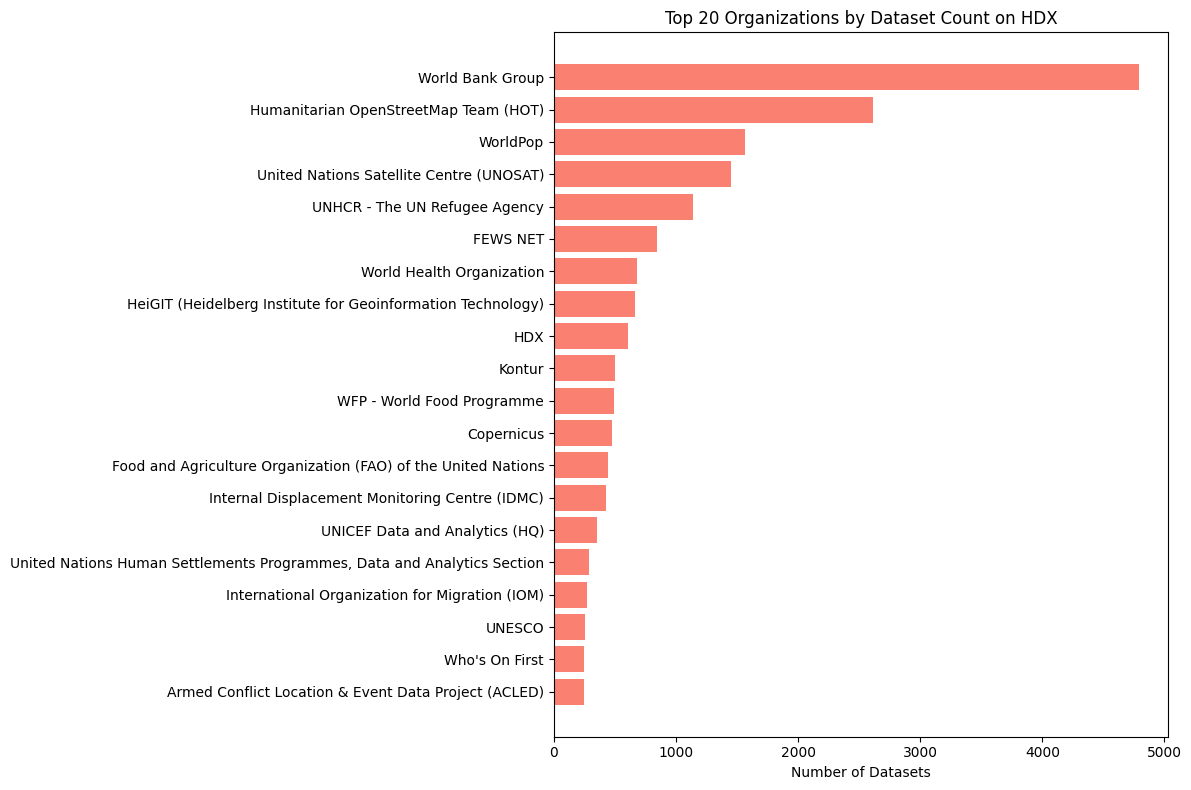

In [10]:
# Visualization of top organizations by datasets
plot_top_facets(org_df, 'Organization', 'Dataset Count',
               title='Top 20 Organizations by Dataset Count on HDX',
               color='salmon')

## Use Case 3: Extract Detailed Metadata for a Specific Dataset

When you already know a dataset's name or ID (visible in its HDX URL or returned by `package_search`), use `package_show` to retrieve its full metadata record. This is useful when you need to:

- Cite a dataset properly (licence, date range, maintainer)
- Contact the data maintainer
- Inspect individual resource files and their download URLs for programmatic access

In [11]:
# Fetch full metadata for a specific dataset by its name/ID
# Note: the dataset name is the slug in the HDX URL, e.g. data.humdata.org/dataset/<name>
dataset_name = "global-iom-dtm-from-api"

response = call_hdx_api('package_show', {'id': dataset_name})
dataset = response['result']
print("Dataset metadata retrieved successfully!")

Dataset metadata retrieved successfully!


In [12]:
# Summary of key metadata fields
metadata = {
    'Title':               dataset.get('title'),
    'Organization':        dataset.get('organization', {}).get('title'),
    'License':             dataset.get('license_title'),
    'Dataset Date Range':  dataset.get('dataset_date'),
    'Update Frequency':    dataset.get('data_update_frequency'),
    'Last Modified':       dataset.get('metadata_modified', '')[:10],
    'Total Downloads':     dataset.get('total_res_downloads', 'N/A'),
    'Page Views (14d)':    dataset.get('pageviews_last_14_days', 'N/A'),
    'Number of Resources': len(dataset.get('resources', [])),
    'Dataset URL':         f"https://data.humdata.org/dataset/{dataset.get('name')}"
}

for key, value in metadata.items():
    print(f"{key:.<40} {value}")

# Description
print("\n" + "="*80)
print(dataset.get('notes', 'No description available'))

Title................................... Global IOM Displacement Tracking Matrix (DTM) from API
Organization............................ International Organization for Migration (IOM)
License................................. Other
Dataset Date Range...................... [2010-06-30T00:00:00 TO 2026-01-31T23:59:59]
Update Frequency........................ 7
Last Modified........................... 2026-02-16
Total Downloads......................... 777
Page Views (14d)........................ 33
Number of Resources..................... 1
Dataset URL............................. https://data.humdata.org/dataset/global-iom-dtm-from-api

This dataset comes from the International Organization for Migration (IOM)'s displacement tracking matrix (DTM) [publicly accessible API](https://dtm.iom.int/data-and-analysis/dtm-api). This API allows the humanitarian community, academia, media, government, and non-governmental organizations to utilize the data collected by DTM. The DTM API only provides

In [13]:
# List all resource files attached to this dataset
resources = [
    {
        'Name':          r.get('name'),
        'Format':        r.get('format'),
        'Size (MB)':     round(r.get('size', 0) / (1024*1024), 2) if r.get('size') else 'N/A',
        'Last Modified': r.get('last_modified', 'N/A')[:10],
        'Download URL':  r.get('download_url') or r.get('url')
    }
    for r in dataset.get('resources', [])
]

df_resources = pd.DataFrame(resources)
print(f"\n{len(resources)} resource file(s):")
df_resources


1 resource file(s):


,Name,Format,Size (MB),Last Modified,Download URL
0,Global IOM DTM data for admin levels 0-2,CSV,33.42,2026-02-16,https://data.humdata.org/dataset/32d0365c-d513...


## Use Case 4: Build an Automated Download Pipeline

Now let's automatically download and load a shapefile from the OCHA Ukraine border crossings dataset. The same pattern can be applied to any dataset and file format. For tabular (CSV) data that is stored in the HDX Tabular Data Endpoints, see the **Advanced** section below.

This pattern is useful for:
- Automated data pipelines that refresh on a schedule
- Batch downloading files across multiple datasets

In [14]:
# Find the most recently updated Ukraine border crossings dataset from OCHA Ukraine
params = {
    'q': 'ukraine border crossings',
    'fq': 'organization:ocha-ukraine',
    'rows': 1,
    'sort': 'metadata_modified desc'
}

response = call_hdx_api('package_search', params)
dataset = response['result']['results'][0]

print(f"Selected: {dataset['title']}")
print(f"ID:       {dataset['name']}")
print(f"Updated:  {dataset['metadata_modified'][:10]}")
print(f"Files:    {len(dataset['resources'])}")
print(f"URL:      https://data.humdata.org/dataset/{dataset['name']}")

Selected: Ukraine: Border Crossings
ID:       ukraine-border-crossings
Updated:  2025-06-12
Files:    4
URL:      https://data.humdata.org/dataset/ukraine-border-crossings


In [15]:
# Extract download URLs for SHP resources only
shp_resources = [
    {
        'Resource Name': r.get('name', 'Unnamed'),
        'Format':        r.get('format'),
        'Size (KB)':     round(r.get('size', 0) / 1024, 2) if r.get('size') else 'N/A',
        'Download URL':  r.get('download_url') or r.get('url')
    }
    for r in dataset['resources']
    if r.get('format', '').upper() == 'SHP'
]

df_shp = pd.DataFrame(shp_resources)
print(f"Found {len(df_shp)} shapefile(s):")
df_shp

Found 1 shapefile(s):


,Resource Name,Format,Size (KB),Download URL
0,UKR_Border_Crossings.zip,SHP,17.52,https://data.humdata.org/dataset/a3ac4e13-e765...


In [16]:
# SHP files on HDX are sometimes zipped so download the zip and read it directly into a GeoDataFrame
shp_url = df_shp['Download URL'].iloc[0]
print(f"Reading shapefile from:\n{shp_url}\n")

r = requests.get(shp_url)
with tempfile.TemporaryDirectory() as tmpdir:
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(tmpdir)
    shp_file = next(Path(tmpdir).rglob('*.shp'))
    gdf = gpd.read_file(shp_file)

print(f"Loaded {len(gdf)} features | Geometry: {gdf.geometry.geom_type.iloc[0]} | CRS: {gdf.crs}")
print(f"Columns: {list(gdf.columns)}")
gdf.head()

Reading shapefile from:
https://data.humdata.org/dataset/a3ac4e13-e765-4b9a-a33f-e7a951c201bf/resource/0ec8429d-5767-4c18-a65b-f9114dd512f4/download/ukr_border_crossings.zip

Loaded 130 features | Geometry: Point | CRS: EPSG:4326
Columns: ['NameEN', 'NameUK', 'Country', 'Type', 'Status', 'Lat', 'Lon', 'StatusDate', 'geometry']


,NameEN,NameUK,Country,Type,Status,Lat,Lon,StatusDate,geometry
0,Vilcha - Oleksandrivka,Вільча - Олександрівка,Belarus,Road,Closed,51.375612,29.409339,2025-05-20,POINT (29.40934 51.37561)
1,Vystupovychi - Nova Rudnia,Виступовичі - Нова Рудня,Belarus,Road,Closed,51.516881,28.985531,2025-05-20,POINT (28.98553 51.51688)
2,Maidan-Kopyshchanskyi - Hlushkevychi,Майдан-Копищанський - Глушкевичі,Belarus,Road,Closed,51.539146,27.845577,2025-05-20,POINT (27.84558 51.53915)
3,Novi Yarylovychi - Nova Huta,Нові Яриловичі - Нова Гута,Belarus,Road,Closed,52.074702,30.969933,2025-05-20,POINT (30.96993 52.0747)
4,Slavutych - Komaryn,Славутич - Комарин,Belarus,Road,Closed,51.399221,30.657726,2025-05-20,POINT (30.65773 51.39922)


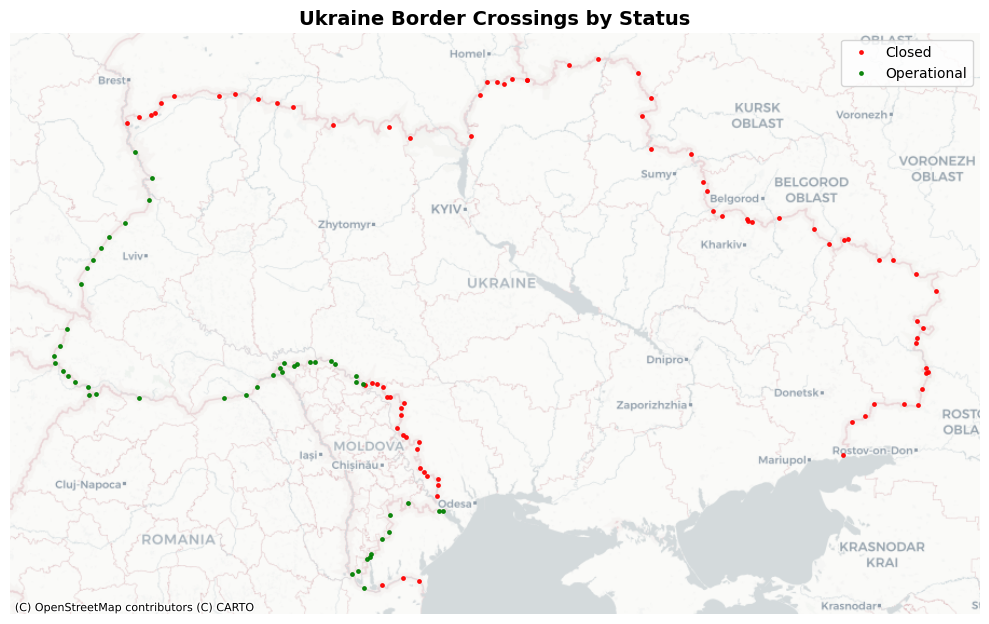

In [17]:
# Plot border crossings coloured by operational status
fig, ax = plt.subplots(figsize=(10, 8))
colors = {'Operational': 'green', 'Closed': 'red'}

# Reproject to Web Mercator (EPSG:3857) so the basemap tiles align correctly
gdf_web = gdf.to_crs(epsg=3857)

for status, group in gdf_web.groupby('Status'):
    group.plot(ax=ax, color=colors.get(status, 'gray'), markersize=6, label=status, alpha=0.9)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Ukraine Border Crossings by Status", fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()

## Advanced: End-to-End Workflow with Tabular Data Endpoints

This section demonstrates a complete pipeline: using the metadata endpoints to locate a dataset, then querying its data content directly via the **Tabular Data Endpoints (TDE)**. See documentation [here](https://docs.humdata.org/build/hdx-apis/tabular-data-endpoints). TDE provides advanced programmatic access to a number of tabular datasets hosted on HDX.

**Scenario:** Your team needs to analyse rainfall data for Afghanistan at admin-level 1.

Steps:
1. `package_search` → find the WFP Afghanistan rainfall dataset
2. Filter resources → identify which are queryable via TDE (`datastore_active=True`)
3. `datastore_info` → inspect the schema
4. `datastore_search` → pull all records with server-side filtering

The TDE helper functions (`show_schema`, `fetch_all_records`, etc.) were defined in the **Setup** section above.

**Column glossary** for the rainfall dataset:
- `rfh` — rainfall, actual (mm, dekadal)
- `rfh_avg` — rainfall, long-term average (mm)
- `rfq` — rainfall anomaly (% of average; >100 = above average)
- `r1h` / `r1q`, `r3h` / `r3q` — 1-month and 3-month rolling totals / anomalies

In [18]:
# Step 1: Find the AFG rainfall dataset from WFP using package_search
params = {
    'q': 'title:rainfall',
    'fq': 'organization:wfp +groups:afg',
    'rows': 1
}

response = call_hdx_api('package_search', params)
afg_dataset = response['result']['results'][0]

print(f"Dataset:      {afg_dataset['title']}")
print(f"Dataset ID:   {afg_dataset['name']}")
print(f"Organization: {afg_dataset['organization']['title']}")

Dataset:      Afghanistan: Rainfall Indicators at Subnational Level
Dataset ID:   afg-rainfall-subnational
Organization: WFP - World Food Programme


In [ ]:
# Step 2: List the resources that are queryable via the TDE (datastore_active=True means the resource is available on TDE)
tde_resources = [
    {'Resource Name': r.get('name'), 'Resource ID': r.get('id')}
    for r in afg_dataset['resources']
    if r.get('datastore_active')
]

df_resources = pd.DataFrame(tde_resources)
print(f"Found {len(df_resources)} TDE-queryable resource(s):")
df_resources

In [20]:
# Step 3: Inspect the schema of the first (full) resource
RAINFALL_RESOURCE_ID = df_resources['Resource ID'].iloc[0]
print(f"Using resource_id: {RAINFALL_RESOURCE_ID}\n")
show_schema(RAINFALL_RESOURCE_ID, "AFG Rainfall")

Using resource_id: 0e6fe8ce-f7c5-4320-bc57-bc95ed7fcd7b

AFG Rainfall schema (15 fields):
  date: timestamp | is_index=False
  adm_level: numeric | is_index=False
  adm_id: numeric | is_index=False
  PCODE: text | is_index=False
  n_pixels: numeric | is_index=False
  rfh: numeric | is_index=False
  rfh_avg: numeric | is_index=False
  r1h: numeric | is_index=False
  r1h_avg: numeric | is_index=False
  r3h: numeric | is_index=False
  r3h_avg: numeric | is_index=False
  rfq: numeric | is_index=False
  r1q: numeric | is_index=False
  r3q: numeric | is_index=False
  version: text | is_index=False


In [21]:
# Step 4: Fetch all admin-level-1 records, selecting only the columns we need
# rfh = rainfall actual, rfh_avg = long-term average, rfq = anomaly (% of avg)
df_rainfall = fetch_all_records(
    RAINFALL_RESOURCE_ID,
    filters={'adm_level': 1},
    fields=['date', 'PCODE', 'rfh', 'rfh_avg', 'rfq']
)

print(f"Fetched {len(df_rainfall)} rows")
df_rainfall.head()

Fetched 55250 rows


,date,PCODE,rfh,rfh_avg,rfq
0,1981-01-01T00:00:00,AF21,11.979259,12.415753,97.493690
1,1981-01-11T00:00:00,AF21,16.127407,11.611309,127.186880
2,1981-01-21T00:00:00,AF21,16.177778,14.391457,109.211900
3,1981-02-01T00:00:00,AF21,13.954074,21.179260,72.401115
4,1981-02-11T00:00:00,AF21,25.062222,21.723803,112.492310


## Next Steps & Resources

You now know how to search the HDX catalogue, inspect metadata, download files, and even query tabular data! You can learn more about them in the documentation [here](https://docs.humdata.org/build/hdx-apis/metadata-endpoints).

- **HDX Metadata Endpoints Documentation**: [TO ADD]
- **Tabular Data Endpoints (TDE) notebook**: For a deeper dive into the TDE, see the [TDE notebook](https://github.com/OCHA-DAP/hdx-tabular-data-endpoints-notebook)
- **HDX Python Library**: For advanced workflows and publishing data, see the [HDX Python Library](https://github.com/OCHA-DAP/hdx-python-api)

### Common Country Codes

Use these in the `groups:` filter:

| Country | Code |
|:---|:---|
| Afghanistan | `afg` |
| Somalia | `som` |
| South Sudan | `ssd` |
| Syria | `syr` |
| Ukraine | `ukr` |
| Yemen | `yem` |

You can find the full list here: https://data.humdata.org/group

### Common Organisation IDs

Use these in the `organization:` filter: `ocha`, `unhcr`, `unicef`, `world-health-organization`, `world-food-programme`.